In [8]:
import torch 
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt 
#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
from model import LSTMLogNormalModel, train_model, sum_regions_predictions 

'''
This script is used to train the model for a specific STATE and forecast the cases on a 
specific year (TEST_YEAR). The model is trained with the regional health data before the year selected. 
'''

'\nThis script is used to train the model for a specific STATE and forecast the cases on a \nspecific year (TEST_YEAR). The model is trained with the regional health data before the year selected. \n'

In [ ]:
model_name = 'base'

columns_to_normalize = ['casos','epiweek', 'biome']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
region = 'Sul'
states =  ['PR']

predict_n = 35
max_epiweek = 17
    
boxcox = False

TEST_YEAR = 2023

In [3]:
print(f'{region} - {TEST_YEAR}')

df = prep.load_cases_data()

df = df.loc[df.uf.isin(regioes_estados[region])]
df = df.loc[df.index >= pd.to_datetime(Week(2015,1).startdate())]
enso = None

# generate the samples to train and test based on the regional data 
X_train, y_train, X_future, norm_values, norm_enso = prep.generate_regional_train_samples(df, enso, TEST_YEAR, max_epiweek = max_epiweek,
                                                                 columns_to_normalize=columns_to_normalize, boxcox = boxcox)

Sul - 2023


In [4]:
X_train.shape

torch.Size([414, 69, 4])

In [5]:
X_future

In [6]:
model = LSTMLogNormalModel(hidden=64, features=len(columns_to_normalize) + 1, 
                        predict_n=52 - max_epiweek)

model

LSTMLogNormalModel(
  (encoder): LSTMEncoder(
    (lstm1): LSTM(4, 64, batch_first=True)
    (lstm2): LSTM(64, 64, batch_first=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (fc_mu): Linear(in_features=64, out_features=35, bias=True)
  (fc_sigma): Linear(in_features=64, out_features=35, bias=True)
)

In [7]:
label = f'{region}_{TEST_YEAR-1}_{model_name}'
batch_size = 1
epochs = 200
verbose = 1
doenca = 'dengue'
min_delta = 0
patience= 30
    
model, hist = train_model(model, X_train, y_train, X_future = None, label=label, batch_size=batch_size, epochs=epochs,
                                                    overwrite=True,
                                                    verbose=verbose, doenca=doenca,
                                                    min_delta = min_delta, patience=patience)

Epoch 1/200 | Train: 0.0898 | Val: 0.0187
Epoch 2/200 | Train: 0.0164 | Val: 0.0140
Epoch 3/200 | Train: 0.0142 | Val: 0.0129
Epoch 4/200 | Train: 0.0135 | Val: 0.0125
Epoch 5/200 | Train: 0.0131 | Val: 0.0126
Epoch 6/200 | Train: 0.0132 | Val: 0.0122
Epoch 7/200 | Train: 0.0128 | Val: 0.0121
Epoch 8/200 | Train: 0.0128 | Val: 0.0121
Epoch 9/200 | Train: 0.0128 | Val: 0.0120
Epoch 10/200 | Train: 0.0128 | Val: 0.0120
Epoch 11/200 | Train: 0.0127 | Val: 0.0122
Epoch 12/200 | Train: 0.0127 | Val: 0.0120
Epoch 13/200 | Train: 0.0127 | Val: 0.0120
Epoch 14/200 | Train: 0.0127 | Val: 0.0119
Epoch 15/200 | Train: 0.0128 | Val: 0.0119
Epoch 16/200 | Train: 0.0127 | Val: 0.0120
Epoch 17/200 | Train: 0.0127 | Val: 0.0119
Epoch 18/200 | Train: 0.0128 | Val: 0.0119
Epoch 19/200 | Train: 0.0128 | Val: 0.0120
Epoch 20/200 | Train: 0.0126 | Val: 0.0119
Epoch 21/200 | Train: 0.0127 | Val: 0.0122
Epoch 22/200 | Train: 0.0127 | Val: 0.0121
Epoch 23/200 | Train: 0.0126 | Val: 0.0119
Epoch 24/200 | Train

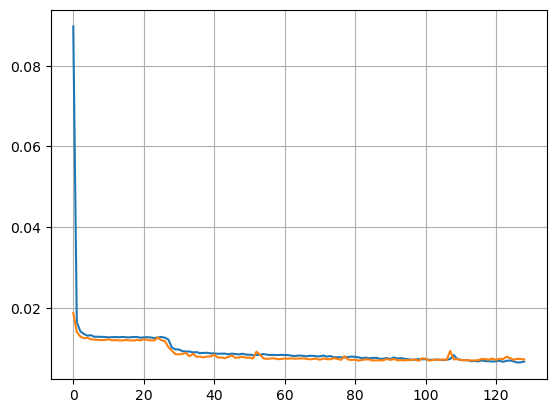

In [10]:
_, ax = plt.subplots()

ax.plot(hist['train_loss'])

ax.plot(hist['val_loss'])

ax.grid()
plt.show()

In [18]:
model

LSTMLogNormalModel(
  (encoder): LSTMEncoder(
    (lstm1): LSTM(4, 64, batch_first=True)
    (lstm2): LSTM(64, 64, batch_first=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (fc_mu): Linear(in_features=64, out_features=35, bias=True)
  (fc_sigma): Linear(in_features=64, out_features=35, bias=True)
)

In [13]:
state = 'PR'

In [15]:
df_d = df.loc[df.uf == state]

df_t = sum_regions_predictions(model, df_d, None, TEST_YEAR, columns_to_normalize, max_epiweek = max_epiweek, boxcox = boxcox, n_passes = 500)

df_t.head()

,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,date
0,12815.720643,11735.072644,14106.135600,10790.561307,15350.255538,10173.452907,16159.944251,9487.235069,16901.874770,2023-04-30
1,9233.103440,8285.269493,10381.572772,7459.379494,11468.172845,7117.460668,12404.810734,6605.361414,12924.180059,2023-05-07
2,6899.036596,6120.714226,8095.834663,5405.025610,9404.727558,5003.761083,10130.617926,4666.336084,11068.724108,2023-05-14
3,4293.813979,3544.713885,5204.701135,3072.640809,6319.450642,2823.934002,6947.282619,2564.051299,7774.423019,2023-05-21
4,2830.441893,2371.131129,3436.790827,1963.952163,4148.351867,1799.277560,4754.836597,1620.241629,5155.590300,2023-05-28


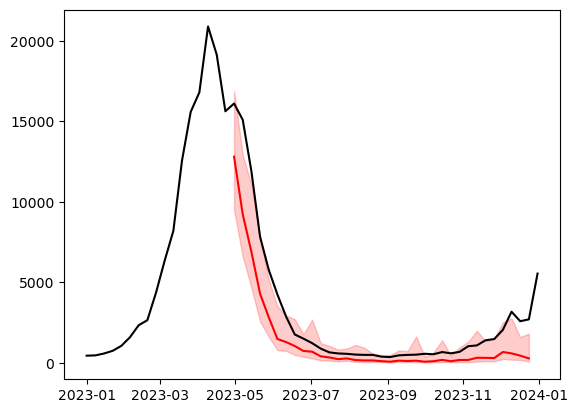

In [17]:
df_d_p = df_d.loc[df_d.index.year == TEST_YEAR]
df_d_p = df_d_p.resample('W-SUN')[['casos']].sum()

_,ax=plt.subplots()

ax.plot(df_d_p.index, df_d_p.casos, color = 'black')

ax.plot(df_t.date, df_t.pred, color = 'red')

ax.fill_between(df_t.date, df_t.lower_95, df_t.upper_95, alpha = 0.2, color = 'red')

plt.show()